<a href="https://colab.research.google.com/github/episode16/Py/blob/master/test/test_okkam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тестовое задание в Okkam

## Основная задача: построить регрессионную модель предсказания зависимой величины с помощью предоставленных факторов. Подзадачи:

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### a) провести разведочный анализ данных (описательные статистики, распределения, сводные таблицы, графики), среди графиков желателен график динамики целевой величины с отметками периодов рекламной активности; содержательно описать результаты анализа;

In [24]:
df = pd.read_excel('./sample_data/data_for_test.xlsx', 'Raw data', index_col=None)
df.to_csv('data_for_test.csv', encoding='utf-8')

description_data = pd.read_excel('./sample_data/data_for_test.xlsx', 'Data description', index_col=None)
description_data.to_csv('data_for_test.csv', encoding='utf-8')
description_data

,Наименование фактора,Описание фактора (единицы измерения)
0,Date,Дата (дни с 1 января 2013 года по 1 февраля 20...
1,Y,Целевой показатель - суммарное количество теле...
2,TV,Показатель медиа активности на национальном те...
3,OOH,OTS по наружной рекламе - оценка числа контакт...
4,Seasonal_Sales,Нормированная в шкалу от 0 (минимум) до 1 (мак...
5,usd_rate,Курс доллара по Yahoo Finance (рублей за 1 дол...


In [25]:
print(f"NaNs in table:\n{df.isna().sum()}\n")


NaNs in table:
Date              0
Y                 3
TV                0
OOH               0
Seasonal_Sales    0
Usd_rate          0
dtype: int64



### Анализ целевой переменной Y

Y
18.0    44
20.0    41
23.0    40
15.0    40
21.0    39
        ..
64.0     1
45.0     1
54.0     1
3.0      1
51.0     1
Name: count, Length: 76, dtype: int64


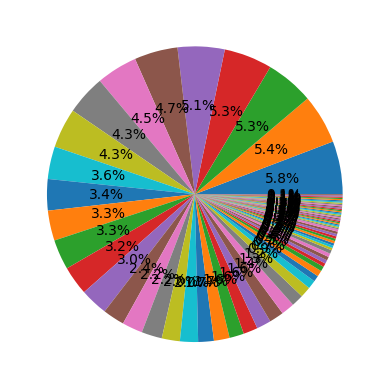

In [28]:
data_y = df['Y'].value_counts()
print(data_y)
plt.pie(data_y, autopct='%1.1f%%')

plt.show()

count    759.000000
mean      23.627141
std       15.081550
min        0.000000
25%       16.000000
50%       21.000000
75%       27.000000
max      176.000000
Name: Y, dtype: float64
[ nan   0.  17.   8.  14.   3.  19.  28.  27.  10.  12.  34.  30.  29.
  26.  13.  15.  40.  18.  31.  23.  36.  32.  42.  39.  35.  37.  54.
  44.  49.  52.  33.  45.  43.  64.  46.  41.  38.  20.  22.  16.  24.
  21. 123.  25.  11.   5.   6.   7.  98.   9.   2. 176.  53.   4.  61.
  59.  68.  47.  55.  50.  72.  91.  82.  77.  74.  63.  73.  80.  57.
  75. 104. 105. 133.  90.  83.  51.]

Mean rate: 23.627140974967062

Median rate: 21.0


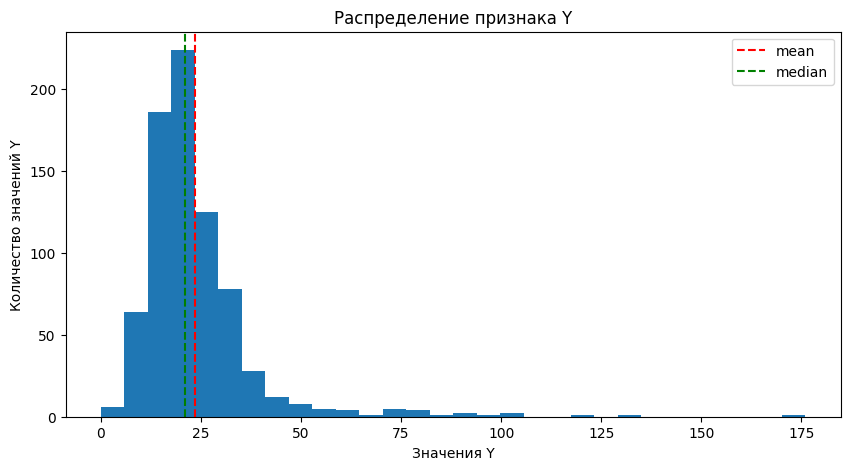

In [40]:

print(df['Y'].describe())
print(df['Y'].unique())
# Визуализация распределения
plt.figure(figsize=(10, 5))
plt.hist(df['Y'], bins=30)
plt.title('Распределение признака Y')
plt.xlabel('Значения Y')
plt.ylabel('Количество значений Y')
mean_Y = df['Y'].mean()
median_Y = df['Y'].median()
plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')
plt.axvline(x=median_Y, color='g', linestyle='--', label='median')
print(f'\nMean rate: {mean_Y}')
print(f'\nMedian rate: {median_Y}')
plt.legend()
plt.show()

### Анализ остальных признаков

TV
0        699
10258      1
9984       1
12512      1
10098      1
        ... 
14987      1
11623      1
18609      1
15449      1
26310      1
Name: count, Length: 64, dtype: int64


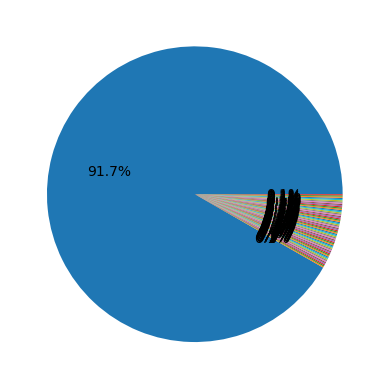

In [41]:
data_tv = df['TV'].value_counts()
print(data_tv)
plt.pie(data_tv, autopct='%1.1f%%')

plt.show()

In [43]:
columns = df.columns
columns[1:]

Index(['Y', 'TV', 'OOH', 'Seasonal_Sales', 'Usd_rate'], dtype='object')

TV
0        699
10258      1
9984       1
12512      1
10098      1
        ... 
14987      1
11623      1
18609      1
15449      1
26310      1
Name: count, Length: 64, dtype: int64


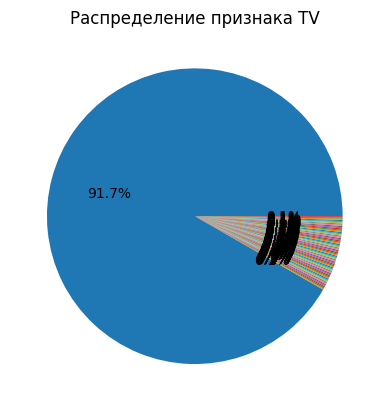

count      762.000000
mean      1040.011811
std       3645.686335
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      26310.000000
Name: TV, dtype: float64
[    0 10258 10355 14445  9268  9604 16736 19522 11509  8934 11443 10038
  8499  9576 22745 11118 13435 10090 17818  6394 13565 10900 15354 15229
  9349 12144 14987 11623 18609 15449 20025 16066 10608 14824  9984 12512
 10098 17367 15391 10313 11547  8872 19871 12565 12813  6533  7490  7826
 10224 16478 11136 12741  8118 13786 10414 11765 12775 11073  6571 10315
 10720 13239 13123 26310]
<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
3      0
4      0
      ..
757    0
758    0
759    0
760    0
761    0
Name: TV, Length: 762, dtype: int64>

Mean rate: 1040.0118110236222

Median rate: 0.0


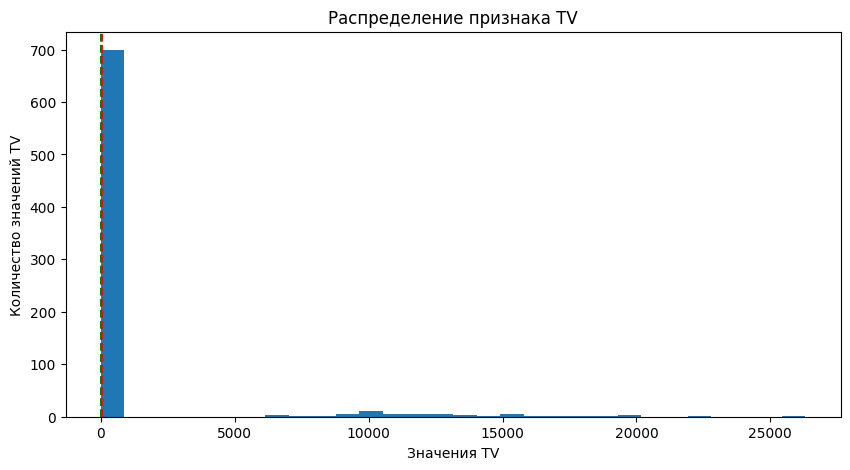

OOH
0.0         747
4018.5        3
3928.5        2
39075.0       1
8439.0        1
12124.5       1
11149.5       1
993.0         1
55543.5       1
57999.0       1
5952.0        1
145137.0      1
783.0         1
Name: count, dtype: int64


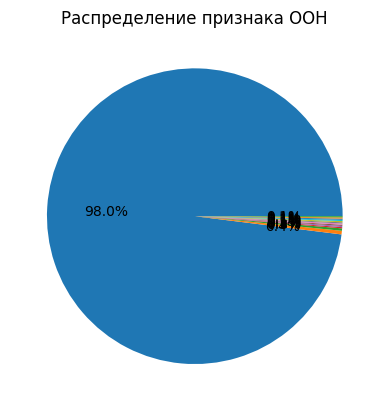

count       762.000000
mean        468.645669
std        6208.391584
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      145137.000000
Name: OOH, dtype: float64
[     0.   39075.    3928.5   8439.   12124.5  11149.5   4018.5    993.
  55543.5  57999.    5952.  145137.     783. ]
<bound method IndexOpsMixin.value_counts of 0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
757    0.0
758    0.0
759    0.0
760    0.0
761    0.0
Name: OOH, Length: 762, dtype: float64>

Mean rate: 468.6456692913386

Median rate: 0.0


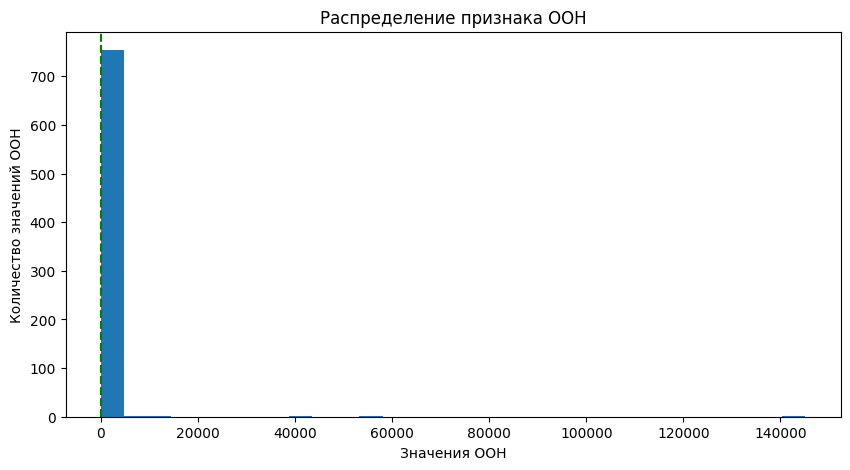

Seasonal_Sales
0.060802    93
0.759700    62
0.134178    62
0.062488    62
0.360924    62
1.000000    62
0.869788    62
0.515319    60
0.360011    60
0.950720    60
0.628615    60
0.000000    57
Name: count, dtype: int64


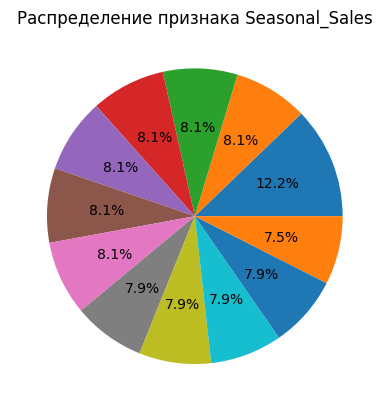

count    762.000000
mean       0.460017
std        0.353072
min        0.000000
25%        0.062488
50%        0.360924
75%        0.759700
max        1.000000
Name: Seasonal_Sales, dtype: float64
[0.06080176 0.         0.75970031 0.51531874 0.13417792 0.36001087
 0.06248752 0.3609245  0.95072042 1.         0.62861483 0.86978773]
<bound method IndexOpsMixin.value_counts of 0      0.060802
1      0.060802
2      0.060802
3      0.060802
4      0.060802
         ...   
757    0.060802
758    0.060802
759    0.060802
760    0.060802
761    0.000000
Name: Seasonal_Sales, Length: 762, dtype: float64>

Mean rate: 0.460017439823213

Median rate: 0.3609244974513023


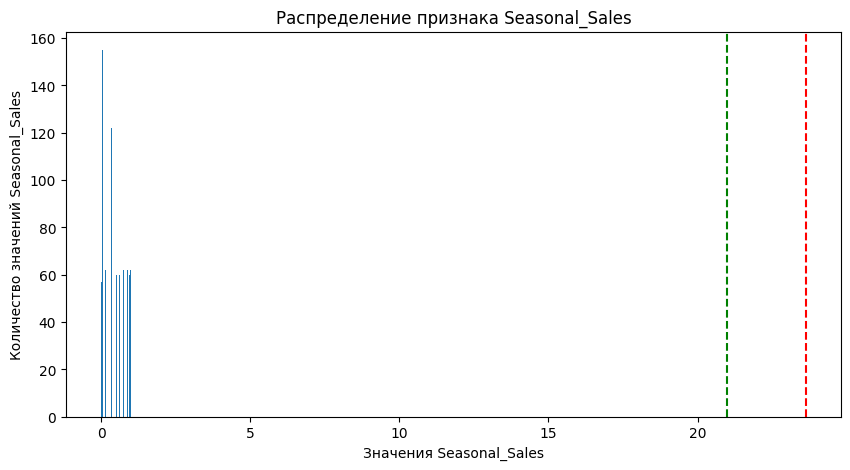

Usd_rate
41.642101    4
34.343201    4
31.667200    4
32.113201    4
68.735001    3
            ..
32.230400    1
32.402599    1
32.342098    1
32.078300    1
33.399200    1
Name: count, Length: 537, dtype: int64


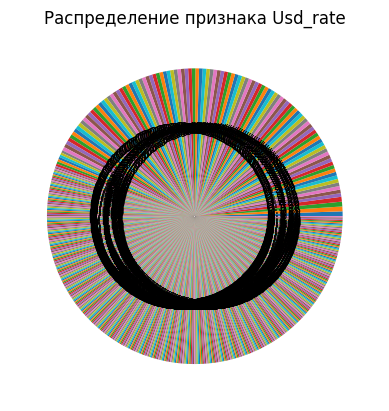

count    762.000000
mean      36.330886
std        8.022390
min       29.883301
25%       32.113201
50%       33.413300
75%       36.036124
max       68.735001
Name: Usd_rate, dtype: float64
[30.502001 30.3372   30.1565   30.271    30.2855   30.358999 30.2745
 30.3433   30.1292   30.264601 30.1464   30.295401 30.300501 30.16
 30.2395   30.2554   30.2162   30.1572   29.989901 29.9865   30.115499
 30.0026   30.032    30.003    29.883301 30.064501 29.9028   30.0515
 30.157301 30.1462   30.0868   29.9944   30.0366   30.0459   30.096001
 30.107201 30.041201 30.2057   30.396299 30.3242   30.5492   30.582199
 30.441999 30.643    30.631701 30.7302   30.571699 30.7153   30.682199
 30.7582   30.6828   30.697201 30.7749   30.723    30.870199 30.812799
 30.953899 30.7869   30.9326   30.726299 30.915501 30.852699 31.056
 31.052799 31.0093   31.0203   31.268499 31.618799 31.5432   31.5961
 31.1898   31.001801 30.833    30.800501 31.0467   31.4443   31.232201
 31.8312   31.493099 31.616199 31.499901 

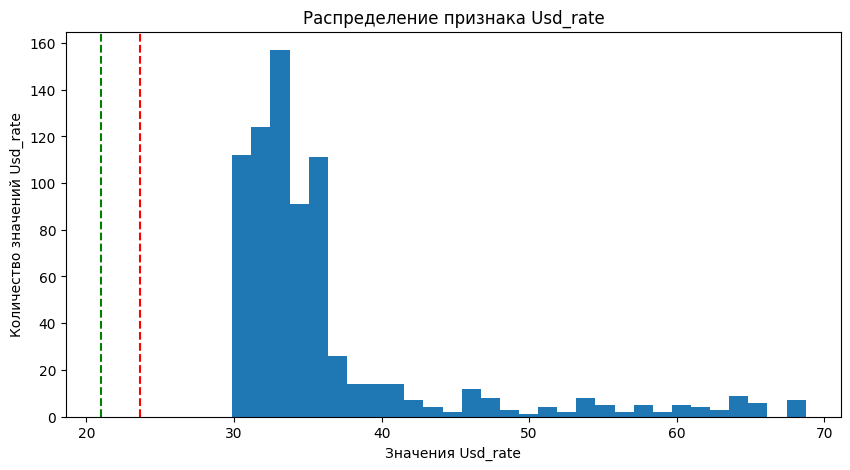

In [50]:
for column in columns[2:]:
  data = df[column].value_counts()
  print(data)
  plt.pie(data, autopct='%1.1f%%')
  plt.title(f'Распределение признака {column}')
  plt.show()

  print(df[column].describe())
  print(df[column].unique())
  print(df[column].value_counts)
  # Визуализация распределения
  plt.figure(figsize=(10, 5))
  plt.hist(df[column], bins=30)
  plt.title(f'Распределение признака {column}')
  plt.xlabel(f'Значения {column}')
  plt.ylabel(f'Количество значений {column}')

  mean_attribute = df[column].mean()
  median_attribute = df[column].median()
  plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')
  plt.axvline(x=median_Y, color='g', linestyle='--', label='median')
  print(f'\nMean rate: {mean_attribute}')
  print(f'\nMedian rate: {median_attribute}')
  #plt.legend()
  plt.show()